In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8') # Hoặc 'ggplot'

def load_stock_price(industry, symbol):
    """
    Hàm đọc file giá của 1 mã chứng khoán.
    Lưu ý: Thay đổi đường dẫn 'Data_Cube' nếu bạn lưu ở chỗ khác.
    """
    path = f"Data_Cube/{industry}/{symbol}/Price_History.csv"
    
    if not os.path.exists(path):
        print(f"Không tìm thấy file: {path}")
        return None
    
    # Đọc CSV
    df = pd.read_csv(path)
    
    # Chuẩn hóa cột ngày tháng
    df['Ngay'] = pd.to_datetime(df['Ngay'])
    
    # Sắp xếp theo thời gian tăng dần
    df = df.sort_values('Ngay').reset_index(drop=True)
    
    return df

# Test thử với mã FPT
df_fpt = load_stock_price("CongNghe", "FPT")

if df_fpt is not None:
    print(f"Đã load FPT: {len(df_fpt)} dòng.")
    print(df_fpt.head())

Đã load FPT: 4759 dòng.
        Ngay  GiaDieuChinh  GiaDongCua     ThayDoi  KhoiLuongKhopLenh  \
0 2006-12-13        395.88       400.0   0(0.00 %)            83530.0   
1 2006-12-14        415.67       420.0  20(5.00 %)           280710.0   
2 2006-12-15        436.46       441.0  21(5.00 %)           265300.0   
3 2006-12-18        458.23       463.0  22(4.99 %)           215790.0   
4 2006-12-19        480.99       486.0  23(4.97 %)           137520.0   

   GiaTriKhopLenh  KLThoaThuan  GtThoaThuan  GiaMoCua  GiaCaoNhat  GiaThapNhat  
0      33412000.0            0            0     400.0       400.0        400.0  
1     117898200.0            0            0     420.0       420.0        420.0  
2     116997300.0            0            0     441.0       441.0        441.0  
3      99910770.0            0            0     463.0       463.0        463.0  
4      66834720.0            0            0     486.0       486.0        486.0  


In [5]:
import pandas as pd

# 1. Đảm bảo cột Ngay là kiểu dữ liệu thời gian (datetime)
df_fpt['Ngay'] = pd.to_datetime(df_fpt['Ngay'])

# 2. Tính mốc thời gian cắt (10 năm trước tính từ hôm nay)
# pd.DateOffset(years=10) giúp trừ đi đúng 10 năm bất kể năm nhuận
cutoff_date = pd.Timestamp.now() - pd.DateOffset(years=10)

print(f"Lọc dữ liệu từ ngày: {cutoff_date.date()}")

# 3. Thực hiện lọc
df_10y = df_fpt[df_fpt['Ngay'] >= cutoff_date].copy()

# Reset lại index cho đẹp (bắt đầu từ 0)
df_10y = df_10y.reset_index(drop=True)

# 4. Kiểm tra kết quả
print(f"Số dòng còn lại: {len(df_10y)}")
print("Dữ liệu đầu (cũ nhất trong 10 năm):")
print(df_10y.head(1))
print("Dữ liệu cuối (mới nhất):")
print(df_10y.tail(1))

Lọc dữ liệu từ ngày: 2016-01-24
Số dòng còn lại: 2491
Dữ liệu đầu (cũ nhất trong 10 năm):
        Ngay  GiaDieuChinh  GiaDongCua      ThayDoi  KhoiLuongKhopLenh  \
0 2016-01-25         46.61        47.1  2.3(5.13 %)           892040.0   

   GiaTriKhopLenh  KLThoaThuan  GtThoaThuan  GiaMoCua  GiaCaoNhat  \
0    4.115400e+10            0            0      45.5        47.1   

   GiaThapNhat    Return  
0         45.0  0.051339  
Dữ liệu cuối (mới nhất):
           Ngay  GiaDieuChinh  GiaDongCua      ThayDoi  KhoiLuongKhopLenh  \
2490 2026-01-16         105.3       105.3  6.8(6.90 %)         23871100.0   

      GiaTriKhopLenh  KLThoaThuan  GtThoaThuan  GiaMoCua  GiaCaoNhat  \
2490    2.472603e+12            0            0      99.5       105.3   

      GiaThapNhat    Return  
2490         99.5  0.069036  


In [6]:
def plot_price(df):
    plt.figure(figsize=(12, 6))

    # Vẽ đường giá
    plt.plot(df['Ngay'], df['GiaDongCua'], label='Giá Đóng Cửa', color='blue', linewidth=1.5)

    # Trang trí biểu đồ
    plt.title('Biểu đồ giá cổ phiếu', fontsize=16)
    plt.xlabel('Năm')
    plt.ylabel('Giá (VND)')
    plt.legend()
    plt.grid(True)
    plt.show()

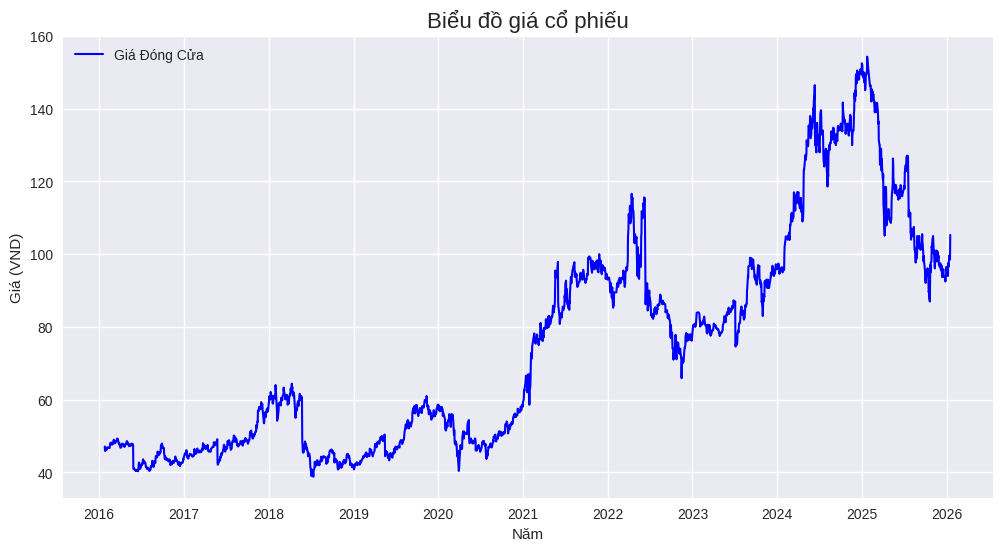

In [7]:
plot_price(df_10y)

In [8]:
def plot_return_hist(df):
    # Tính % thay đổi giá hàng ngày
    df['Return'] = df['GiaDongCua'].pct_change()

    # Vẽ Histogram để xem phân phối lợi nhuận
    plt.figure(figsize=(10, 5))
    df['Return'].hist(bins=50, color='green', alpha=0.7)
    plt.title('Phân phối lợi nhuận ngày của FPT')
    plt.xlabel('Mức thay đổi (%)')
    plt.ylabel('Tần suất')
    plt.show()

    # In ra ngày giảm mạnh nhất và tăng mạnh nhất
    worst_day = df.loc[df['Return'].idxmin()]
    best_day = df.loc[df['Return'].idxmax()]

    print(f"Ngày giảm mạnh nhất: {worst_day['Ngay'].date()} ({worst_day['Return']:.2%})")
    print(f"Ngày tăng mạnh nhất: {best_day['Ngay'].date()} ({best_day['Return']:.2%})")

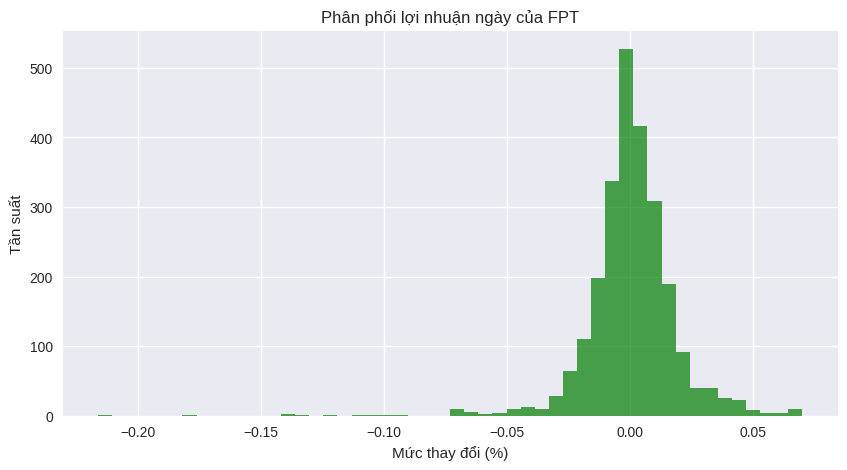

Ngày giảm mạnh nhất: 2022-06-13 (-21.64%)
Ngày tăng mạnh nhất: 2021-01-29 (7.00%)


In [9]:
plot_return_hist(df_10y)

        Ngay  GiaDongCua_HPG  GiaDongCua_HSG
0 2008-12-05            28.3            32.0
1 2008-12-08            26.9            30.4
2 2008-12-09            27.8            28.9
3 2008-12-10            27.2            27.5
4 2008-12-11            27.7            26.2
           Ngay  GiaDongCua_HPG  GiaDongCua_HSG
4263 2026-01-12           27.50            16.3
4264 2026-01-13           27.25            16.2
4265 2026-01-14           27.25            16.3
4266 2026-01-15           27.60            17.0
4267 2026-01-16           27.60            16.7
Ma trận tương quan:
                GiaDongCua_HPG  GiaDongCua_HSG
GiaDongCua_HPG        1.000000        0.667377
GiaDongCua_HSG        0.667377        1.000000


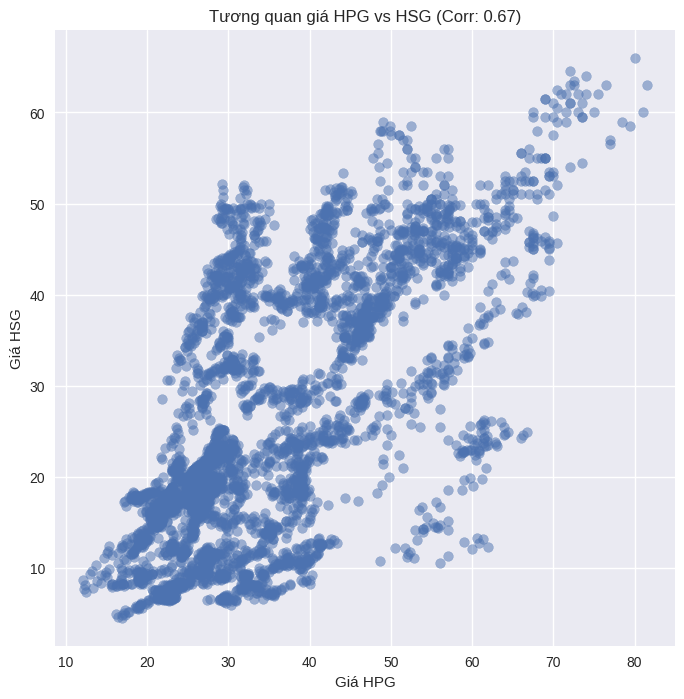

In [10]:
# Load 2 mã (Giả sử bạn đã crawl đủ dữ liệu)
# Lưu ý: Cần đảm bảo file tồn tại trong thư mục tương ứng
df_hpg = load_stock_price("NguyenVatLieu", "HPG")
df_hsg = load_stock_price("NguyenVatLieu", "HSG")

if df_hpg is not None and df_hsg is not None:
    # Merge 2 dataframe theo ngày để so sánh cùng mốc thời gian
    df_compare = pd.merge(df_hpg[['Ngay', 'GiaDongCua']], 
                          df_hsg[['Ngay', 'GiaDongCua']], 
                          on='Ngay', suffixes=('_HPG', '_HSG'))
    
    print(df_compare.head(5))
    print(df_compare.tail(5))
    
    # Tính ma trận tương quan
    corr = df_compare[['GiaDongCua_HPG', 'GiaDongCua_HSG']].corr()
    print("Ma trận tương quan:")
    print(corr)

    # Vẽ Scatter Plot
    plt.figure(figsize=(8, 8))
    plt.scatter(df_compare['GiaDongCua_HPG'], df_compare['GiaDongCua_HSG'], alpha=0.5)
    plt.title(f"Tương quan giá HPG vs HSG (Corr: {corr.iloc[0,1]:.2f})")
    plt.xlabel('Giá HPG')
    plt.ylabel('Giá HSG')
    plt.show()